In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Indoor_Plant_Health_and_Growth_Factors.csv")
data

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score
0,Sansevieria cylindrica,17.39,17,8,Yellowing leaves,205,3,3h direct morning sun,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1
1,Aloe vera,9.84,31,9,NaN,191,1,3h direct morning sun,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2
2,Ficus lyrata,19.82,40,8,Brittle leaves,477,5,Indirect light all day,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1
3,Monstera deliciosa,37.08,11,1,New bud,207,1,Low light corner,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4
4,Ficus lyrata,2.96,26,3,Wilting,465,2,Filtered sunlight through curtain,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,Leaf drop,370,4,6h full sun,32.4,58.0,Compost,96,Fungus gnats,High,31.7,Sandy,3
996,Schefflera arboricola,26.60,44,0,Yellowing leaves,91,3,Filtered sunlight through curtain,24.3,39.4,Compost,14,Spider mites,Low,32.9,Silty,4
997,Monstera deliciosa,9.69,13,0,NaN,134,4,3h direct morning sun,26.4,52.4,NaN,80,Spider mites,Low,58.5,Peaty,5
998,Epipremnum aureum,23.54,16,7,Brittle leaves,442,3,3h direct morning sun,18.7,60.1,Organic,97,Fungus gnats,Moderate,24.8,Loamy,2


In [2]:
# Drop irrelevant columns
data = data.drop(columns=["Fertilizer_Type", "Fertilizer_Amount_ml", "Pest_Presence", "Pest_Severity", "Soil_Type","Health_Score", "Height_cm", "Leaf_Count", "New_Growth_Count", "Health_Notes",  "Sunlight_Exposure"])
data

,Plant_ID,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%
0,Sansevieria cylindrica,205,3,21.7,77.5,51.9
1,Aloe vera,191,1,22.6,68.9,28.2
2,Ficus lyrata,477,5,17.2,44.3,13.6
3,Monstera deliciosa,207,1,25.0,72.2,38.4
4,Ficus lyrata,465,2,23.2,51.6,37.9
...,...,...,...,...,...,...
995,Sansevieria cylindrica,370,4,32.4,58.0,31.7
996,Schefflera arboricola,91,3,24.3,39.4,32.9
997,Monstera deliciosa,134,4,26.4,52.4,58.5
998,Epipremnum aureum,442,3,18.7,60.1,24.8


In [3]:
# Convert from milliliters to seconds for watering with the flow rate of 10ml/sec
data["Pump_time"] = data["Watering_Amount_ml"] / 10
data = data.drop(columns=["Watering_Amount_ml"])
data

,Plant_ID,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Pump_time
0,Sansevieria cylindrica,3,21.7,77.5,51.9,20.5
1,Aloe vera,1,22.6,68.9,28.2,19.1
2,Ficus lyrata,5,17.2,44.3,13.6,47.7
3,Monstera deliciosa,1,25.0,72.2,38.4,20.7
4,Ficus lyrata,2,23.2,51.6,37.9,46.5
...,...,...,...,...,...,...
995,Sansevieria cylindrica,4,32.4,58.0,31.7,37.0
996,Schefflera arboricola,3,24.3,39.4,32.9,9.1
997,Monstera deliciosa,4,26.4,52.4,58.5,13.4
998,Epipremnum aureum,3,18.7,60.1,24.8,44.2


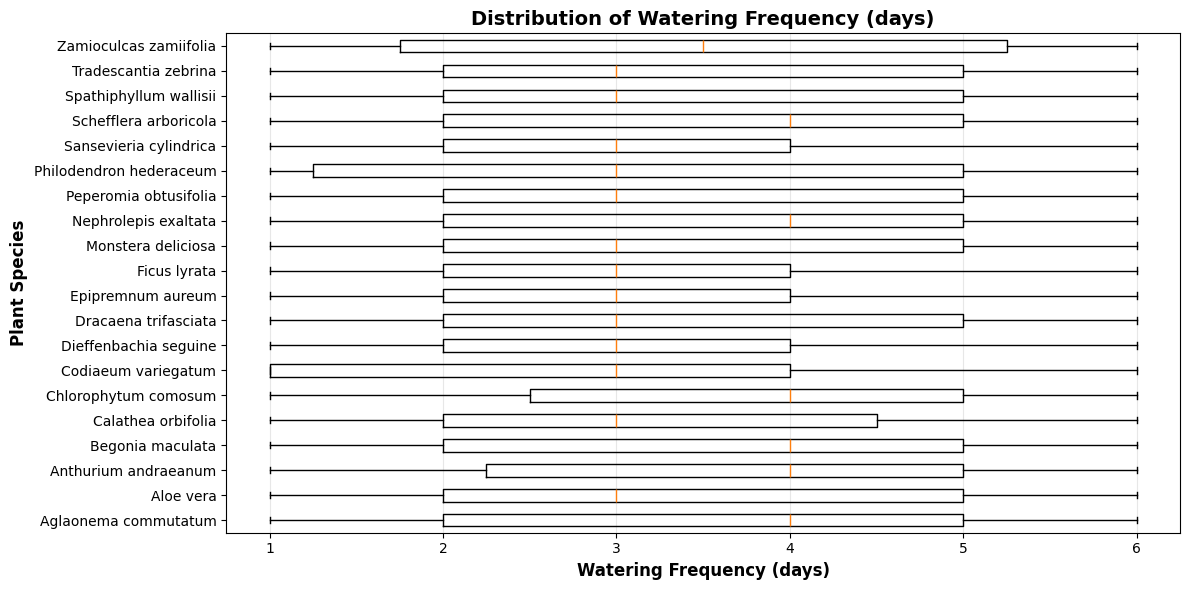

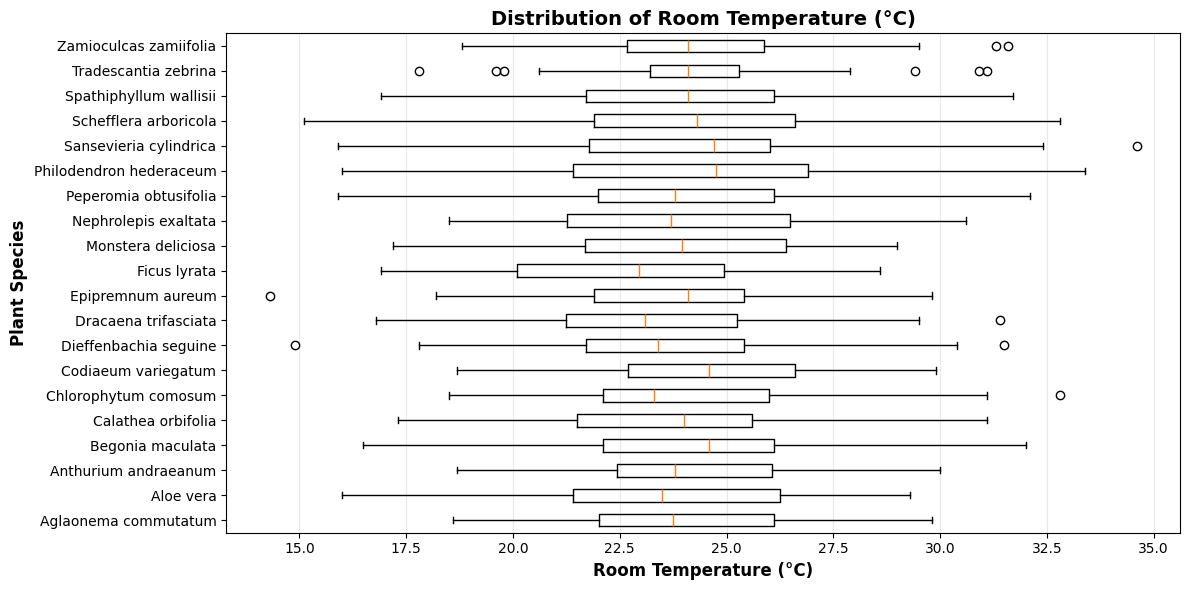

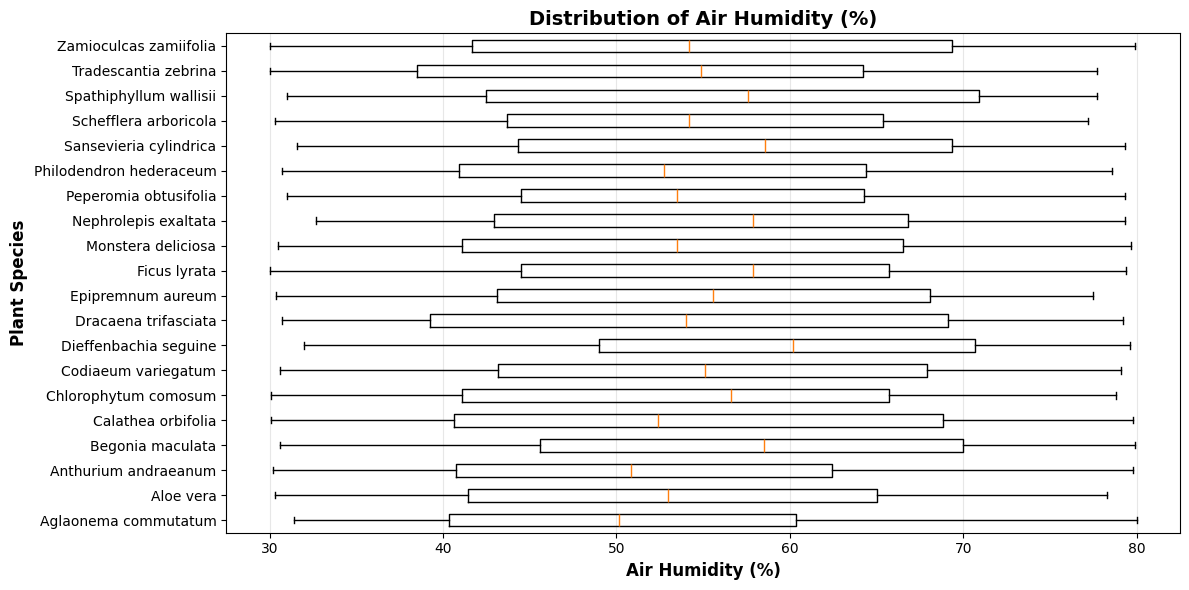

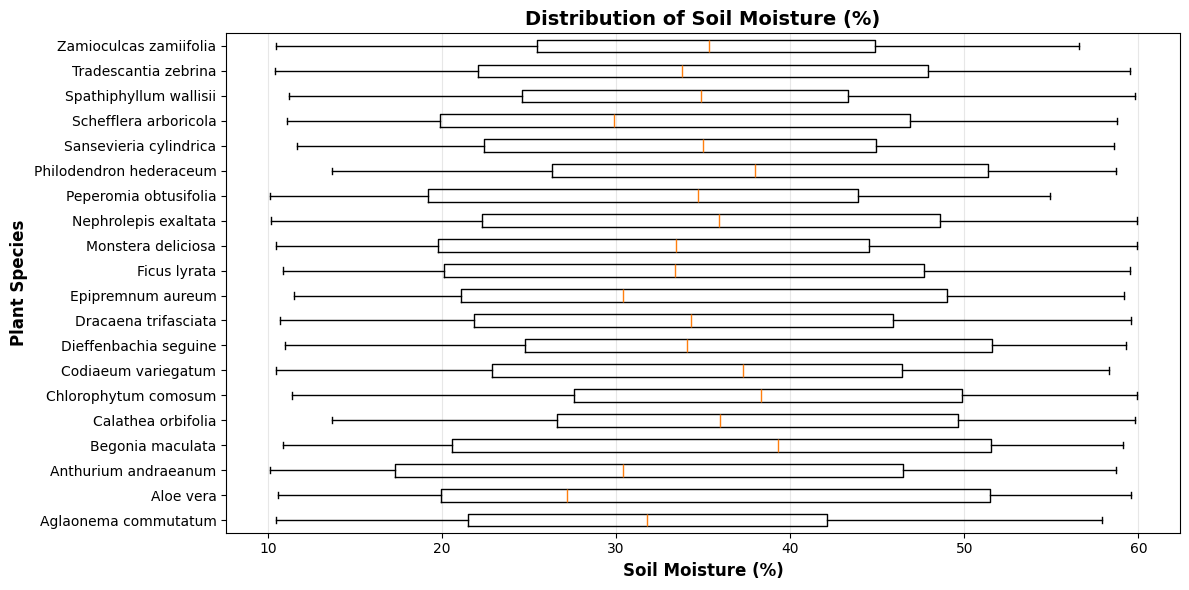

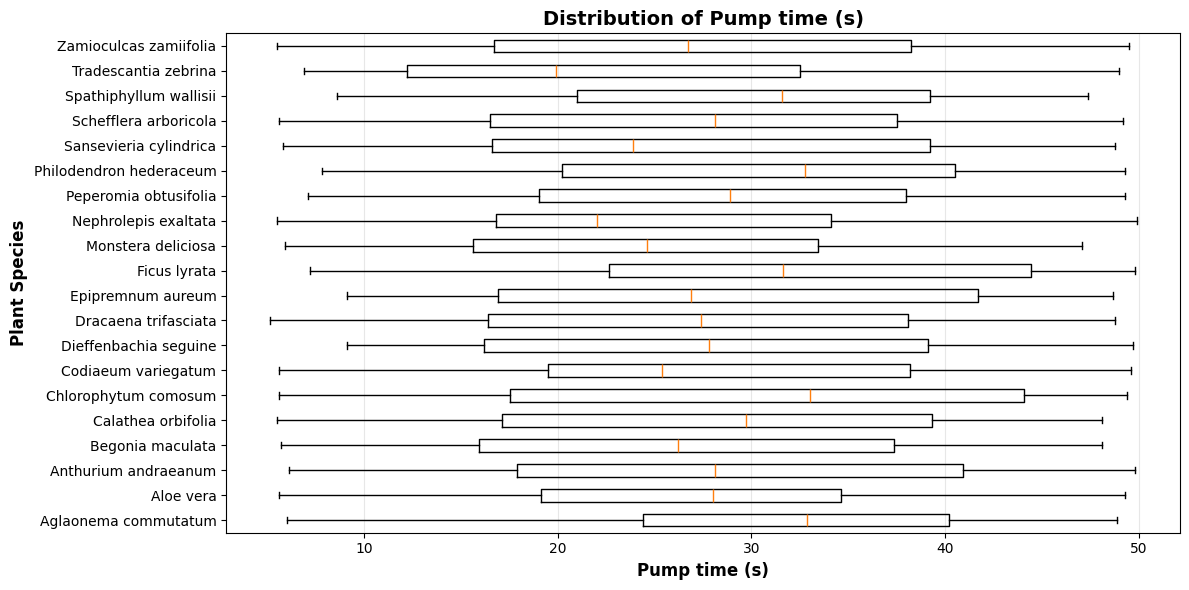

In [4]:
# Outliers
# Get unique plants
plants = sorted(data['Plant_ID'].unique())

# Define metrics
metrics = ['Watering_Frequency_days', 'Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Pump_time']
metric_labels = ['Watering Frequency (days)', 'Room Temperature (°C)', 'Air Humidity (%)', 'Soil Moisture (%)', 'Pump time (s)']

# Create boxplots for each metric
for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):

    fig, ax = plt.subplots(figsize=(12, 6))

    # Prepare data for each plant
    data_list = [data[data['Plant_ID'] == plant][metric].dropna().values for plant in plants]

    # Create horizontal boxplot
    ax.boxplot(data_list, tick_labels=plants, vert=False)
    ax.set_xlabel(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Plant Species', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {label}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

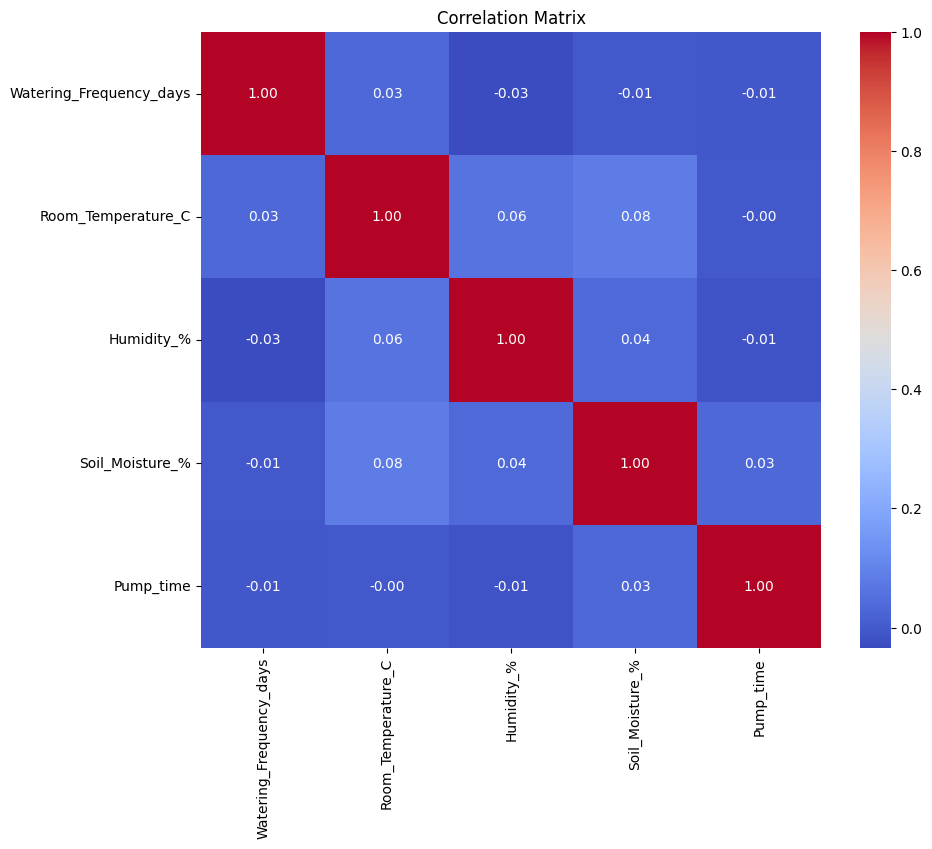

In [5]:
# Correlation matrix
numeric_data = data.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [6]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numeric_data)
data_scaled = pd.DataFrame(data_scaled, columns=numeric_data.columns)
data_scaled

,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Pump_time
0,-0.241588,-0.711257,1.582300,1.183854,-0.597361
1,-1.381152,-0.426450,0.985277,-0.450113,-0.709863
2,0.897977,-2.135289,-0.722489,-1.456692,1.588390
3,-1.381152,0.333034,1.214367,0.253113,-0.581289
4,-0.811370,-0.236579,-0.215713,0.218641,1.491960
...,...,...,...,...,...
995,0.328195,2.674776,0.228584,-0.208810,0.728554
996,-0.241588,0.111518,-1.062654,-0.126077,-1.513448
997,0.328195,0.776066,-0.160176,1.638883,-1.167906
998,-0.241588,-1.660612,0.374369,-0.684522,1.307136
